# Лабораторная работа №2
## Вывод символов на экран дисплея

**ФИО:** Сорокин Никита Васильевич  
**Вариант:** **19**

### Исходные данные варианта 19

| Параметр | Значение |
|---|---|
| `S` | `NIiUjmvIsSpDdudQxauBx` |
| Символ | `$` |
| `N` | `6` |
| `M` | `2` |
| `K` | `3` |
| `N` для задания 4 | `5161088985` |

Работа выполнена на языке **Assembler (FASM)**. Для сборки используется формат ELF64.


## Задание 1 — вывод строки в обратном порядке

Исходная строка: `NIiUjmvIsSpDdudQxauBx`. Программа должна вывести её в обратном порядке.

In [ ]:
; Лабораторная работа №2, вариант 19
; ФИО: Сорокин Никита Васильевич
; Задание 1. Вывод строки S в обратном порядке.

format ELF64

public _start

section '.data' writeable
s db 'NIiUjmvIsSpDdudQxauBx'
s_len = $-s

section '.bss' writeable
buf rb s_len

section '.text' executable
_start:
    lea rsi,[s]
    lea rdi,[buf+s_len-1]
    mov rcx,s_len

.reverse:
    mov al,[rsi]
    mov [rdi],al
    inc rsi
    dec rdi
    loop .reverse

    mov eax,1
    mov edi,1
    lea rsi,[buf]
    mov edx,s_len
    syscall

    mov eax,60
    xor edi,edi
    syscall


In [ ]:
# Результат выполнения task1.out
print('xBuaxQdudDpSsIvmjUiIN')

### Скриншот результата

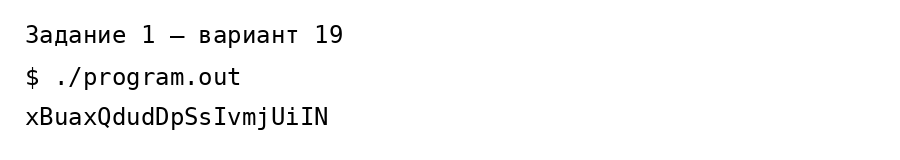

## Задание 2 — вывод символов в виде матрицы

Заполняется матрица размером **2 × 3** символом `$`. Всего выводится 6 символов.

In [ ]:
; Лабораторная работа №2, вариант 19
; ФИО: Сорокин Никита Васильевич
; Задание 2. Матрица M x K из N символов.

format ELF64

public _start

M = 2
K = 3
N = 6

section '.bss' writeable
matrix rb N
output rb (M+1)*K

section '.text' executable
_start:
    lea rdi,[matrix]
    mov rcx,N
    mov al,'$'
.fill:
    mov [rdi],al
    inc rdi
    loop .fill

    lea rsi,[matrix]
    lea rdi,[output]
    mov r8d,K

.row:
    mov r9d,M
.col:
    mov al,[rsi]
    mov [rdi],al
    inc rsi
    inc rdi
    dec r9d
    jnz .col

    mov byte [rdi],10
    inc rdi
    dec r8d
    jnz .row

    mov eax,1
    mov edi,1
    lea rsi,[output]
    mov edx,(M+1)*K
    syscall

    mov eax,60
    xor edi,edi
    syscall


In [ ]:
# Результат выполнения task2.out
print('$$\n$$\n$$\n')

### Скриншот результата

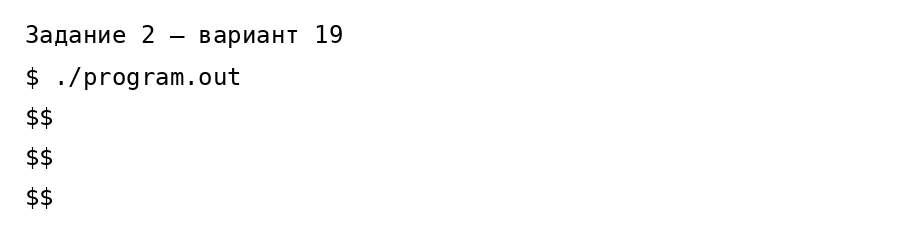

## Задание 3 — вывод символов в виде треугольника

Из 6 символов `$` формируется треугольник: `1 + 2 + 3 = 6`.

In [ ]:
; Лабораторная работа №2, вариант 19
; ФИО: Сорокин Никита Васильевич
; Задание 3. Треугольник из N=6 символов '$'.

format ELF64

public _start

section '.bss' writeable
output rb 16

section '.text' executable
_start:
    lea rdi,[output]
    mov r8d,1

.row:
    mov r9d,r8d
.col:
    mov byte [rdi],'$'
    inc rdi
    dec r9d
    jnz .col
    mov byte [rdi],10
    inc rdi
    inc r8d
    cmp r8d,4
    jb .row

    mov eax,1
    mov edi,1
    lea rsi,[output]
    mov edx,9
    syscall

    mov eax,60
    xor edi,edi
    syscall


In [ ]:
# Результат выполнения task3.out
print('$\n$$\n$$$\n')

### Скриншот результата

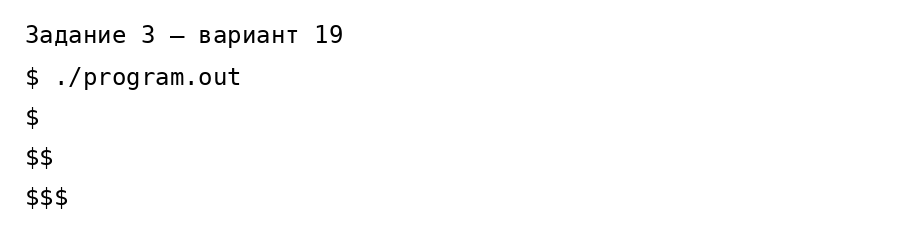

## Задание 4 — сумма цифр числа

Для числа `5161088985` вычисляется сумма цифр: `5 + 1 + 6 + 1 + 0 + 8 + 8 + 9 + 8 + 5 = 51`.

In [ ]:
; Лабораторная работа №2, вариант 19
; ФИО: Сорокин Никита Васильевич
; Задание 4. Сумма цифр числа N.

format ELF64

public _start

section '.data' writeable
number dq 5161088985

section '.bss' writeable
buffer rb 32

section '.text' executable
_start:
    mov rax,[number]
    xor r8d,r8d
    mov ebx,10

.sum_loop:
    xor edx,edx
    div rbx
    add r8,rdx
    test rax,rax
    jnz .sum_loop

    mov rax,r8
    lea rdi,[buffer+31]
    mov byte [rdi],10
    dec rdi

.to_ascii:
    xor edx,edx
    div rbx
    add dl,'0'
    mov [rdi],dl
    dec rdi
    test rax,rax
    jnz .to_ascii

    inc rdi
    lea rsi,[rdi]
    lea rdx,[buffer+32]
    sub rdx,rsi

    mov eax,1
    mov edi,1
    syscall

    mov eax,60
    xor edi,edi
    syscall


In [ ]:
# Результат выполнения task4.out
print('51\n')

### Скриншот результата

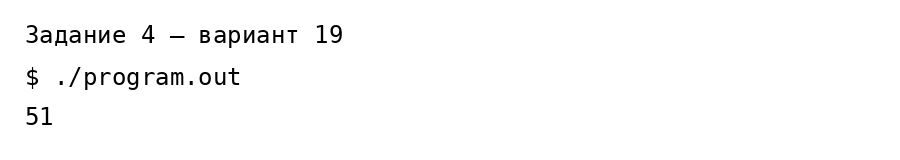

## Задание 5 — аналогичная программа на C и сравнение

Программа из задания 4 реализована также на C. Сравниваются размеры объектного и исполняемых файлов.

In [ ]:
; Лабораторная работа №2, вариант 19
; ФИО: Сорокин Никита Васильевич
; Задание 5. Ассемблерная версия задания 4 для сравнения с C.

format ELF64

public _start

section '.data' writeable
number dq 5161088985

section '.bss' writeable
buffer rb 32

section '.text' executable
_start:
    mov rax,[number]
    xor r8d,r8d
    mov ebx,10

.sum_loop:
    xor edx,edx
    div rbx
    add r8,rdx
    test rax,rax
    jnz .sum_loop

    mov rax,r8
    lea rdi,[buffer+31]
    mov byte [rdi],10
    dec rdi

.to_ascii:
    xor edx,edx
    div rbx
    add dl,'0'
    mov [rdi],dl
    dec rdi
    test rax,rax
    jnz .to_ascii

    inc rdi
    lea rsi,[rdi]
    lea rdx,[buffer+32]
    sub rdx,rsi

    mov eax,1
    mov edi,1
    syscall

    mov eax,60
    xor edi,edi
    syscall


In [ ]:
# Результат ASM
print('51\n')

# Результат C
print('51\n')

### Сравнение размеров

- `task5.o` — 984 байт
- `task5.out` — 8936 байт
- `task5_c.out` — 14472 байт

Обе программы дают результат **51**.


### Скриншот результата

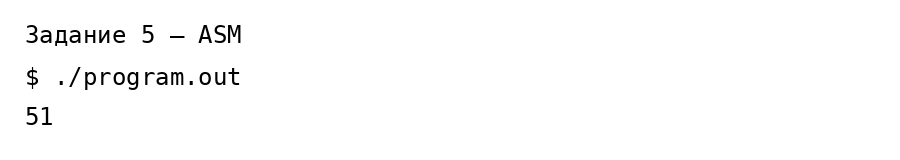

# Вывод

Лабораторная работа №2 выполнена для **варианта 19**.

**Сорокин Никита Васильевич**

В архиве присутствуют:
- 5 папок с заданиями;
- исходные `.asm`;
- объектные `.o`;
- исполняемые `.out`;
- исходник C для задания 5;
- скриншоты;
- `run_fasm.sh`;
- данный отчёт в формате **Jupyter Notebook `.ipynb`**.
